# Kibitz — Model Training

This notebook trains the two models for Kibitz:
1. **Board Detector** (YOLOv8n-pose) — finds the 4 corners of the chessboard
2. **Piece Classifier** (MobileNetV3-Small) — classifies each of 64 squares into 13 classes

**Prerequisites:** You should have already generated synthetic data with Blender (see `GUIDE.md`, Phase 1).

Run each cell in order. The notebook explains what each step does.

## 0. Verify Setup

In [1]:
import torch
import platform

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"\nUsing device: {device}")

Python: 3.12.2
PyTorch: 2.11.0
MPS available: True
CUDA available: False

Using device: mps


In [2]:
# Verify synthetic data exists
from pathlib import Path

DATA_DIR = Path('data/synthetic')
images = sorted((DATA_DIR / 'images').glob('*.png'))
labels = sorted((DATA_DIR / 'labels').glob('*.json'))

print(f"Images: {len(images)}")
print(f"Labels: {len(labels)}")

if len(images) == 0:
    print("\n⚠ No images found! Run the Blender data generation first (see GUIDE.md, Phase 1).")
elif len(images) < 100:
    print(f"\n⚠ Only {len(images)} images. Consider generating more (1000+ recommended for decent results).")
else:
    print(f"\n✓ Dataset looks good.")

Images: 4063
Labels: 4063

✓ Dataset looks good.


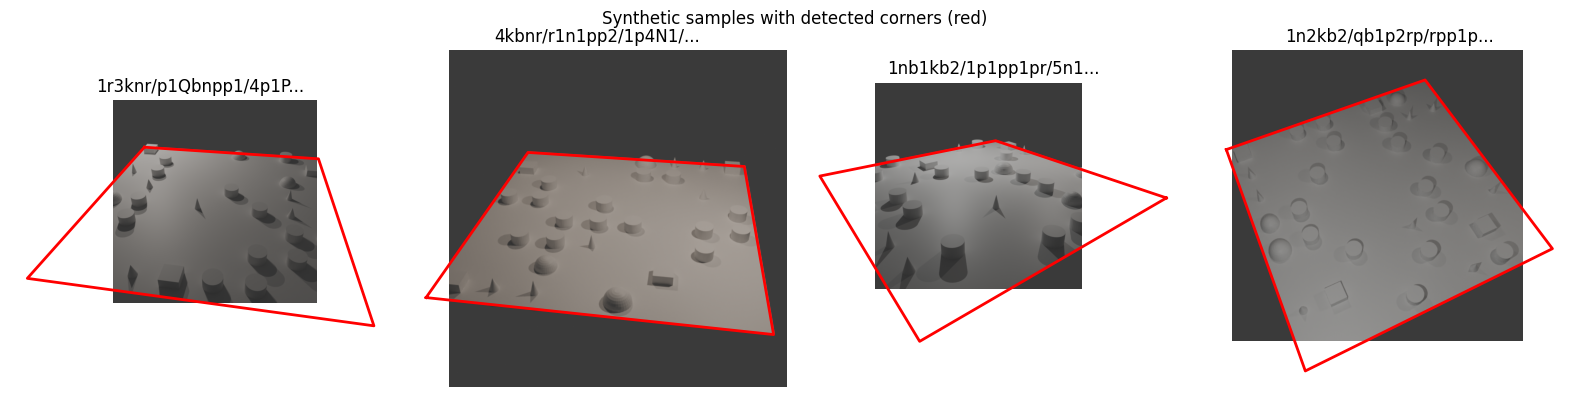

In [3]:
# Preview a few samples
import json
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, min(4, len(images)), figsize=(16, 4))
if len(images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, images[:4]):
    img = Image.open(img_path)
    ax.imshow(img)
    
    # Load and show corners
    label_path = DATA_DIR / 'labels' / img_path.with_suffix('.json').name
    with open(label_path) as f:
        ann = json.load(f)
    corners = ann['corners']
    xs = [c[0] for c in corners] + [corners[0][0]]
    ys = [c[1] for c in corners] + [corners[0][1]]
    ax.plot(xs, ys, 'r-', linewidth=2)
    ax.set_title(ann['fen'].split(' ')[0][:20] + '...')
    ax.axis('off')

plt.suptitle('Synthetic samples with detected corners (red)')
plt.tight_layout()
plt.show()

## 1. Train Board Detector (YOLOv8n-pose)

This model finds the 4 corners of the chessboard in the image. It uses YOLOv8 nano with pose estimation (keypoint detection) — a small, fast model ideal for mobile.

**What happens:**
1. Synthetic annotations are converted to YOLO keypoint format
2. Data is split 90/10 train/val
3. YOLOv8n-pose is fine-tuned on our data

**Expected time:** 30-90 minutes on M2 Mac.

In [6]:
# Convert annotations and train
# This calls train_detector.py which handles everything

import sys
!{sys.executable} train_detector.py \
    --data data/synthetic/ \
    --epochs 100 \
    --output runs/detector

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/williamrevah/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Preparing dataset...
Training YOLOv8n-pose...
Ultralytics 8.4.32 🚀 Python-3.12.2 torch-2.11.0 CPU (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=runs/detector/dataset/dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=No

In [9]:
# Check training results
from pathlib import Path

best_model = Path('runs/detector/train/weights/best.pt')
if best_model.exists():
    size_mb = best_model.stat().st_size / 1024 / 1024
    print(f"✓ Best model saved: {best_model} ({size_mb:.1f} MB)")
else:
    print("⚠ No best.pt found. Check training output above for errors.")
    # Try to find it elsewhere
    for p in Path('runs').rglob('best.pt'):
        print(f"  Found: {p}")

✓ Best model saved: runs/detector/train/weights/best.pt (6.1 MB)


## 2. Train Piece Classifier (MobileNetV3-Small)

This model classifies each of the 64 squares into one of 13 classes:
- `empty` (no piece)
- 6 white pieces: `wP, wR, wN, wB, wQ, wK`
- 6 black pieces: `bP, bR, bN, bB, bQ, bK`

**What happens:**
1. Each square is cropped from the synthetic images using perspective transform
2. Crops are organized by class into folders
3. MobileNetV3-Small (pretrained on ImageNet) is fine-tuned on our crops

**Expected time:** 20-60 minutes on M2 Mac.

In [ ]:
!{sys.executable} train_classifier.py \
    --data data/synthetic/ \
    --epochs 50 \
    --output runs/classifier

Using device: mps
Extracting square crops from synthetic data...


In [ ]:
# Check classifier results
best_classifier = Path('runs/classifier/best.pt')
if best_classifier.exists():
    checkpoint = torch.load(best_classifier, map_location='cpu')
    print(f"✓ Best classifier saved: {best_classifier}")
    print(f"  Val accuracy: {checkpoint['val_acc']:.4f}")
    print(f"  Epoch: {checkpoint['epoch']}")
    print(f"  Classes: {checkpoint['class_names']}")
else:
    print("⚠ No best.pt found. Check training output above for errors.")

## 3. Export to ONNX

Both models are converted to ONNX format for browser deployment via ONNX Runtime Web.

The classifier uses a dynamic batch dimension so all 64 squares can be classified in a single inference call.

In [ ]:
!{sys.executable} export_onnx.py \
    --detector runs/detector/train/weights/best.pt \
    --classifier runs/classifier/best.pt \
    --output ../models/

In [ ]:
# Verify exported models
models_dir = Path('../models')
for name in ['board-detect.onnx', 'piece-classify.onnx']:
    p = models_dir / name
    if p.exists():
        size_mb = p.stat().st_size / 1024 / 1024
        print(f"✓ {name}: {size_mb:.1f} MB")
    else:
        print(f"⚠ {name}: NOT FOUND")

total = sum(p.stat().st_size for p in models_dir.glob('*.onnx')) / 1024 / 1024
print(f"\nTotal model size: {total:.1f} MB (target: <10 MB for GitHub Pages)")

## 4. Deploy

Run these commands in your terminal (not in this notebook):

```bash
cd ~/Dev/kibitz
git add models/board-detect.onnx models/piece-classify.onnx
git commit -m "feat: add trained ONNX models (v1, synthetic data)"
git push
```

Then test on your phone at https://w2ur.github.io/kibitz/